# Parametric Structural Optimization

In this notebook, we explore the minimization of compliance of a parametric structure made of a linear elastic material. The structure is parametrized by N bars, each of which has M segments. We seek the ideal configuration of the Y coordinates of the vertices that connect those bar segments.

Although topology optimization is a common approach to structural optimization, here we demonstrate the possibility of incorporating a design space into the optimization process. The design space is defined using a geometry library called PyVista, which does not support automatic differentiation. However, we can enable differentiability by using a finite difference approximation of the Jacobian matrix.

We denote the design space as a function $g$ that maps the design variables to a signed distance field. Then, we can then define the density field $\rho(\mathbf{x})$ as a function of the SDF value $g(\mathbf{x})$. Finally we denote the differentiable finite element method (FEM) solver as $f$, which takes the density field as input and returns the structure's compliance.  Therefore, the optimization problem can be formulated as follows:

\begin{equation}
\min_{\mathbf{y}} f(\rho(g(\mathbf{y}))).
\end{equation}

Here, $\mathbf{y}$ is the vector of design variables (the Y coordinates of the vertices).

## AD and Tesseracts

Since we want use a gradient based optimizer, we need to compute the gradient of the compliance with respect to the design variables. Hence we are interested in the following derivative:

\begin{equation}
\frac{\partial f}{\partial \mathbf{y}} = \frac{\partial f}{\partial \rho} \cdot \frac{\partial \rho}{\partial g} \cdot \frac{\partial g}{\partial \mathbf{y}}.
\end{equation}

Note that each term is a Jacobian matrix. With automatic differentiation libraries such as JAX, backpropagation uses the vector-Jacobian product to pull back the gradients over the entire pipeline.

Implementing the pipeline $f \circ \rho \circ g$ in a single project is difficult because we have to implement parts of the backpropagation ourselves. With the Tesseract library, however, we can wrap each function in a separate module and then compose them together. To enable differentiability, we can also define AD-relevant endpoints, such as the vector-Jacobian product, inside the tesseract module.

Prior to running this notebook, we need to build the required Tesseracts by running the following commands in the terminal:

```bash
$ tesseract build design_tess/
$ tesseract build fem_tess/
```

To understand more about building and running Tesseracts, please refer to the [Tesseract documentation](https://docs.pasteurlabs.ai/projects/tesseract-core/latest/).

## Design Space Tesseract

First, let's import the tesseract_core library and serve the design space tesseract, which is equivalent to the function $g$ in the equation above.


In [136]:
import jax.numpy as jnp
from tesseract_core import Tesseract

In [137]:
design = Tesseract.from_image("design")
design.serve()

Let's setup the parameters for the design space and apply the design tesseract. The tesseract internally constructs a 3D geometry using PyVista and computes the signed distance field (SDF).

In [138]:
n_chains = 4
n_edges_per_chain = 5
bar_radius = 0.7
bar_overlap = 0.35

Lx = 60
Ly = 30
Nx = 120
Ny = 60

# Initialize chain parameter array
params = jnp.zeros((n_chains, n_edges_per_chain + 1, 3), dtype=jnp.float32)

for chain in range(n_chains):
    params = params.at[chain, :, 0].set(
        jnp.linspace(
            -Lx/2, 
            Lx/2, 
            n_edges_per_chain + 1))

    # add an offset
    params = params.at[chain, :, 1].set(chain / n_chains * 5.0 - 2.5)

sdf = design.apply(
    {
        "bar_params": params,
        "bar_radius": bar_radius,
        "bar_overlap": bar_overlap,
        "Lx": Lx,
        "Ly": Ly,
        "Nx": Nx,
        "Ny": Ny,
        "epsilon": 1e-3, # epsilon, only used for FD of the jacobian
    }
)["sdf"]

print("SDF shape:", sdf.shape)

/anaconda/envs/top/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


SDF shape: (120, 60)


Now import some plotting functions and visualize the structure and its SDF field.

/anaconda/envs/top/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


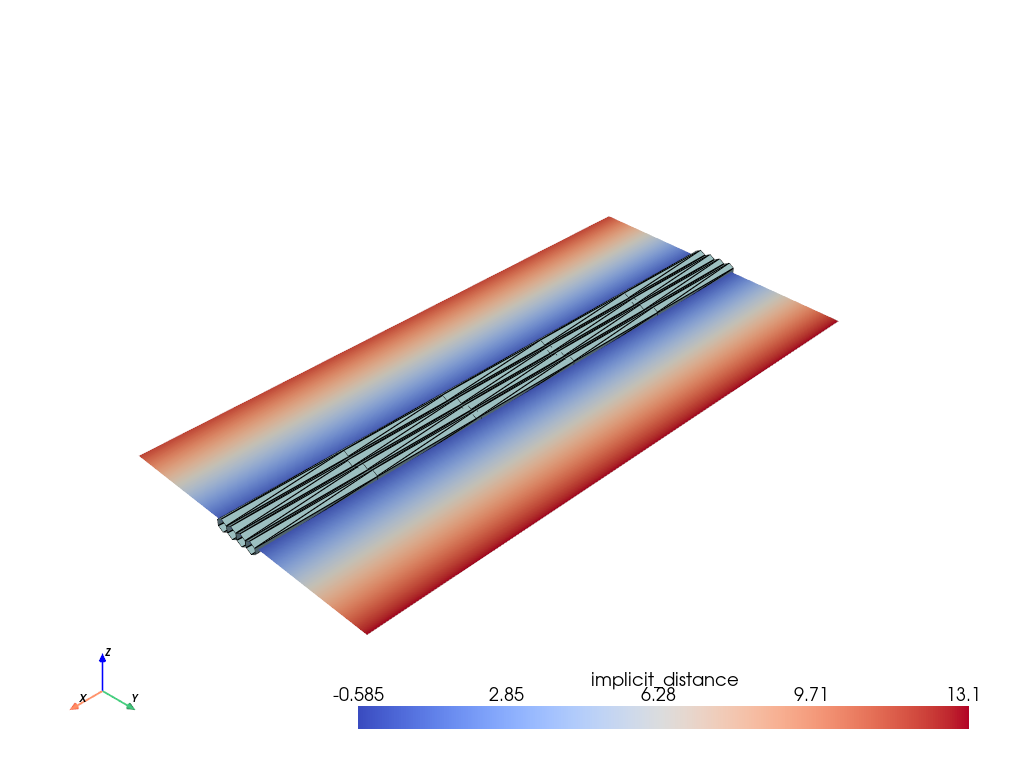

In [139]:
from design_tess.tesseract_api import build_geometry, sdf_plane
import pyvista as pv

def visualize(params):
    """Visualize the geometry defined by the parameters."""
    geometry = build_geometry(
        params,
        radius=bar_radius,
        overlap=bar_overlap)

    plane = sdf_plane(
        params, 
        radius=bar_radius,
        overlap=bar_overlap,
        Lx=Lx,
        Ly=Ly,
        Nx=Nx,
        Ny=Ny)

    plotter = pv.Plotter()
    plotter.add_mesh(geometry, color='lightblue', show_edges=True, edge_color='black')
    plotter.add_axes()
    plotter.add_mesh(plane, scalars="implicit_distance", cmap='coolwarm', show_edges=False)
    plotter.show()

visualize(params)

Instead of calling the apply endpoint we can also call the vector-Jacobian product endpoint which is used for backpropagation. This endpoint computes the Jacobian of the SDF with respect to the design variables, which is useful for gradient-based optimization. Hence we define the ``vjp_inputs`` as ``bar_params`` and the ``vjp_outputs`` as ``sdf``. 

In [118]:
grad = design.vector_jacobian_product(
    inputs = {
        "bar_params": params,
        "bar_radius": bar_radius,
        "bar_overlap": bar_overlap,
        "Lx": Lx,
        "Ly": Ly,
        "Nx": Nx,
        "Ny": Ny,
        "epsilon": 1e-3, # epsilon, only used for FD of the jacobian
    },
    vjp_inputs = ["bar_params"],
    vjp_outputs = ["sdf"],
    cotangent_vector = {
        "sdf": jnp.ones((Nx, Ny), dtype=jnp.float32)
    }
)["bar_params"]

print("Gradient shape:", grad.shape)

Gradient shape: (4, 6, 3)


Instead of manually supplying all the relevant information regarding the vjp inputs, ouputs and the cotangent vector we can use the tesseract-jax library. Tesseract-jax automatically registers the AD endpoints from the tesseract as lowering primitives in JAX. We can see this in action by using the ``jax.jvp`` function.

In [119]:
from tesseract_jax import apply_tesseract
import jax

primal, vjp_fun = jax.vjp(
    lambda params : apply_tesseract(
        design,
        {
            "bar_params": params,
            "bar_radius": bar_radius,
            "bar_overlap": bar_overlap,
            "Lx": Lx,
            "Ly": Ly,
            "Nx": Nx,
            "Ny": Ny,
            "epsilon": 0.01,  # Smoothing parameter for SDF computation
        }
    )["sdf"],
    params
)

grad = vjp_fun(jnp.ones((Nx, Ny), dtype=jnp.float32))[0]

print("Gradient shape:", grad.shape)


Gradient shape: (4, 6, 3)


## SDF to Density Field

Now that we have the signed distance field (SDF) from the design space, we can proceed to compute the density field, that is we need to define the function $\rho$ that maps the SDF to a density value. This function needs to be smooth and differentiable to ensure that the optimization process can effectively navigate the design space. We use a parametrized sigmoid function, which ensures that the density values are bounded between 0 and 1. Here $s$ is the slope of the sigmoid and $o$ is the offset. The parameters $s$ and $o$ can be adjusted to control the steepness and position of the transition between 0 and 1 in the density field.

\begin{equation}
    \rho(\text{SDF}) = \frac{1}{1 + e^{s \cdot \text{SDF} - o}}
\end{equation}

Since this function is straight forward to implement, we can directly use the JAX library to define it.

In [120]:
def sdf_to_rho(
   sdf: jnp.ndarray, 
   scale: float = 4.0, 
   offset: float = 1.0
) -> jnp.ndarray:
   """
   Convert signed distance function to material density using sigmoid.
   
   Args:
       sdf: Signed distance function values.
       scale: Sigmoid steepness (higher = sharper transition).
       offset: SDF value where density = 0.5.
       
   Returns:
       Material density field in [0,1].
   """
   return 1 / (1 + jnp.exp(scale * sdf - offset))

To verify the conversion, we can visualize the density field:

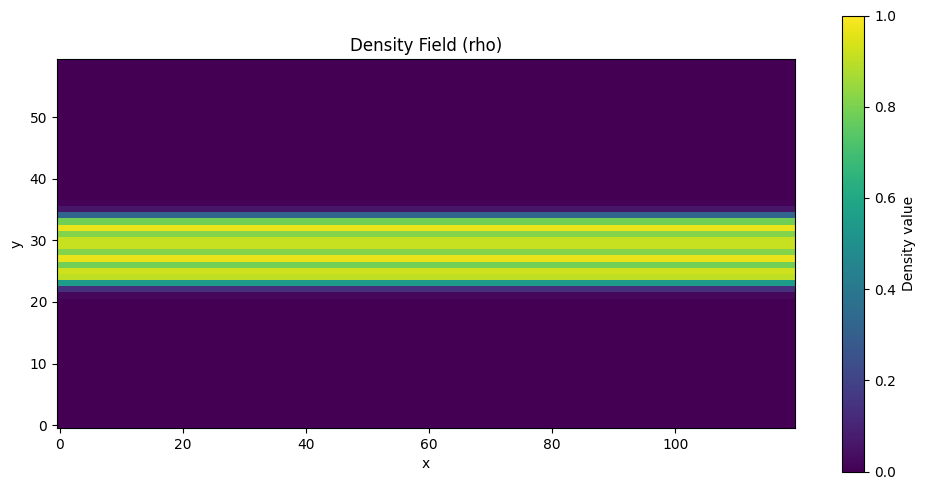

In [124]:
import matplotlib.pyplot as plt

rho = sdf_to_rho(sdf)
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(
    rho.T,
    origin="lower",
    cmap="viridis",
    vmin=0,
    vmax=1
)
ax.set_title("Density Field (rho)")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.colorbar(im, ax=ax, label="Density value")
plt.tight_layout()

## FEM Tesseract

Now that we have a density field, we compute the compliance the structure. The compliance tesseract is using the jax-fem finite library internally. Jax-FEM is a fully differentiable finite element library. Inside the tesseract the boundary conditions are already hard coded, where the entire left side is a dirichlet boundary condition and bottom right side is a neumann boundary condition. 

In [126]:
fem = Tesseract.from_image("jax-fem-structure")
fem.serve()

We use tesseract in combination tesseract-jax to compute the compliance of the structure.

In [128]:
compliance = apply_tesseract(
    fem,
    {
        "rho": jnp.reshape(rho, (Nx * Ny, 1)),
        "Lx": Lx,
        "Ly": Ly,
        "Nx": Nx,
        "Ny": Ny,
    }
)["compliance"]
print(f"Compliance: {compliance:.4f}")

Compliance: 14564.3838


## Parametric Topology Optimization

Now that we have all the components of the pipeline, we can compose them together and define the loss function for the optimization. The loss function is simply the compliance of the structure, which we can compute by applying the FEM tesseract to the density field obtained from the design space tesseract.

In [130]:
import optax

def loss(params: jnp.ndarray) -> float:
   """
   Compute structural compliance for given bar parameters.
   
   Args:
       params: Bar parameter array with shape (n_chains, n_nodes, 3).
       
   Returns:
       Structural compliance (scalar). Lower values indicate better performance.
   """
   # Generate signed distance field from design parameters
   sdf = apply_tesseract(
       design,
       {
           "bar_params": params,
           "bar_radius": bar_radius,
           "bar_overlap": bar_overlap,
           "Lx": Lx,
           "Ly": Ly,
           "Nx": Nx,
           "Ny": Ny,
           "epsilon": 0.01,  # epsilon for finite difference
       }
   )["sdf"]
   
   # Convert SDF to material density distribution
   rho = sdf_to_rho(sdf)
   
   # Compute structural compliance via finite element analysis
   compliance = apply_tesseract(
       fem,
       {
           "rho": jnp.reshape(rho, (Nx * Ny, 1)),  # Flatten for FEM solver
           "Lx": Lx,
           "Ly": Ly,
           "Nx": Nx,
           "Ny": Ny,
       }
   )["compliance"]
   
   return compliance

Now we can use JAX's `grad` function to compute the gradient of the compliance with respect to the design variables. Furthermore we use the Adam optimizer as defined in optax to perform the optimization. Note that for structural optimization, there are better optimizers available, such as MMA, but for simplicity we use Adam here. The optimization process will take a few minutes to run.

In [131]:
solver = optax.adam(learning_rate=0.4)
opt_state = solver.init(params)

los_hist = []
params_hist = []

for i in range(80):
    loss_value, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = solver.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    los_hist.append(loss_value)
    params_hist.append(params)

    print(f"Iteration {i+1}, Loss: {loss_value:.4f}")

Iteration 1, Loss: 14564.3838
Iteration 2, Loss: 11865.4453
Iteration 3, Loss: 10175.6338
Iteration 4, Loss: 9206.2979
Iteration 5, Loss: 8504.4883
Iteration 6, Loss: 8100.1436
Iteration 7, Loss: 7670.9912
Iteration 8, Loss: 7511.6714
Iteration 9, Loss: 7304.8745
Iteration 10, Loss: 7051.6621
Iteration 11, Loss: 6865.5000
Iteration 12, Loss: 6603.3457
Iteration 13, Loss: 6329.5078
Iteration 14, Loss: 6074.6982
Iteration 15, Loss: 5841.0928
Iteration 16, Loss: 5597.3862
Iteration 17, Loss: 5349.0049
Iteration 18, Loss: 5111.0806
Iteration 19, Loss: 4866.7988
Iteration 20, Loss: 4569.6489
Iteration 21, Loss: 4243.5571
Iteration 22, Loss: 3833.2053
Iteration 23, Loss: 3338.1294
Iteration 24, Loss: 2823.3789
Iteration 25, Loss: 2412.7334
Iteration 26, Loss: 2091.5920
Iteration 27, Loss: 1857.6984
Iteration 28, Loss: 1695.9998
Iteration 29, Loss: 1603.3392
Iteration 30, Loss: 1537.8438
Iteration 31, Loss: 1487.2103
Iteration 32, Loss: 1421.2256
Iteration 33, Loss: 1362.4247
Iteration 34, Lo

Lets plot the compliance as a function of the optimization steps. We can see that the compliance is decreasing smoothly, indicating that the optimization is working as expected. 

Text(0.5, 1.0, 'Compliance over Iterations')

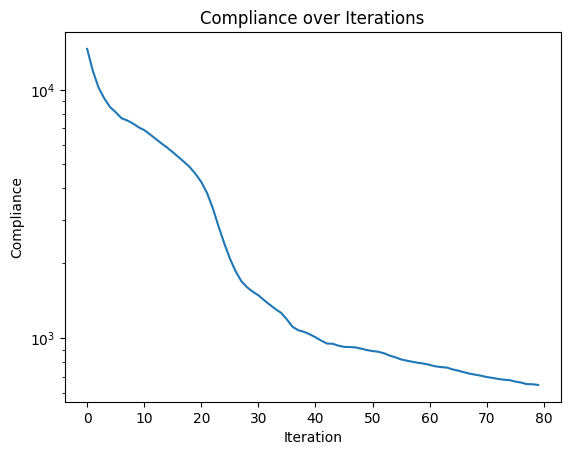

In [132]:
plt.plot(los_hist)
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Compliance")
plt.title("Compliance over Iterations")

We can also visualize the optimized structure and its SDF field.

/anaconda/envs/top/lib/python3.12/site-packages/pyvista/jupyter/notebook.py:36: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


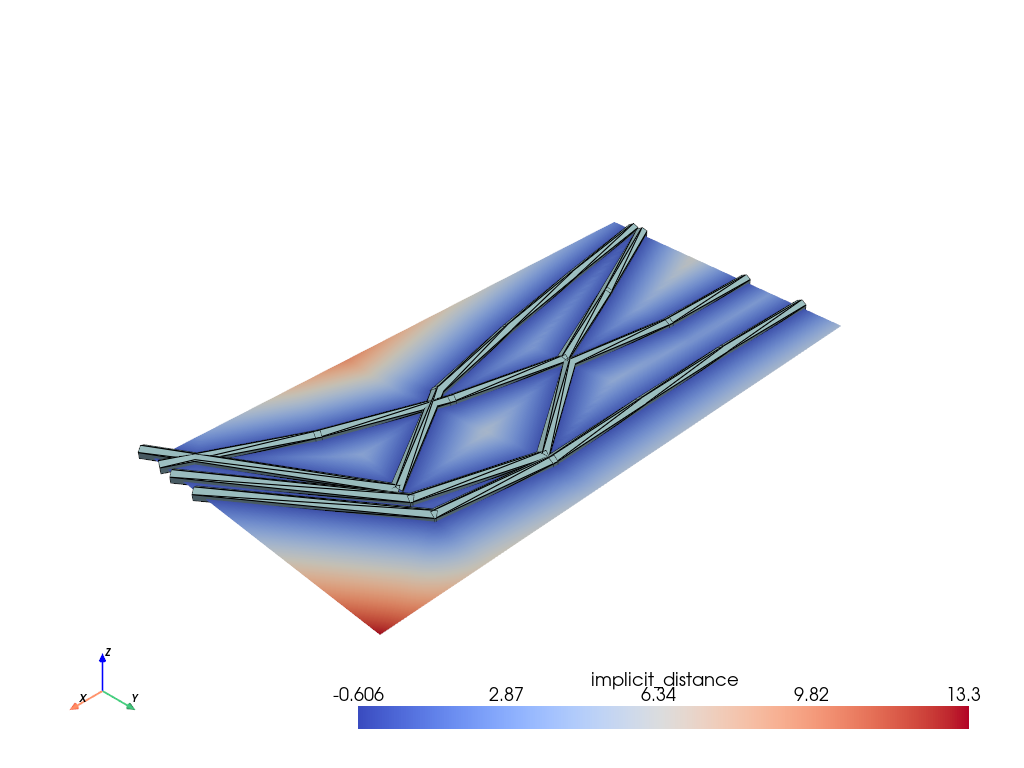

In [133]:
visualize(params)

And finally we generate a video of the optimization process to visualize how the structure evolves over time.

In [135]:
from matplotlib import animation

# repeat the last frame a few times to show the final result
params_hist = params_hist + [params] * 20

fig = plt.figure()

ims = []
for params in params_hist:
    sdf = apply_tesseract(
        design,
        {
            "bar_params": params,
            "bar_radius": bar_radius,
            "bar_overlap": bar_overlap,
            "Lx": Lx,
            "Ly": Ly,
            "Nx": Nx,
            "Ny": Ny,
            "epsilon": 1e-3,
        }
    )["sdf"]
    
    rho = sdf_to_rho(sdf)
    
    im = plt.imshow(
        rho.T,
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    ims.append([im])

ani = animation.ArtistAnimation(fig, ims, interval=10, blit=True, repeat_delay=1000)
plt.close(fig)

ani.save("rho_optim.gif", writer="pillow", fps=20)


In [ ]:
ani.to_jshtml()